In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [4]:
import pandas as pd

df = pd.read_csv(
    "uk-counties.csv",
    engine="python",
    on_bad_lines="skip"
)

print(df.head())
print(df.columns)

       county_name  country county_type
0     Bedfordshire  England    Historic
1        Berkshire  England    Historic
2  Buckinghamshire  England    Historic
3   Cambridgeshire  England    Historic
4         Cheshire  England    Historic
Index(['county_name', 'country', 'county_type'], dtype='str')


In [6]:
text_cols = df.select_dtypes(include=['object', 'string']).columns

print("Possible text columns:", list(text_cols))

if len(text_cols) == 0:
    raise ValueError("No text columns found in the DataFrame.")

text_column = text_cols[0]

print("Using column:", text_column)

Possible text columns: ['county_name', 'country', 'county_type']
Using column: county_name


In [7]:
df[text_column] = df[text_column].astype(str)

# Basic cleaning
df[text_column] = df[text_column].str.lower()
df[text_column] = df[text_column].str.replace(r'[^a-zA-Z\s]', '', regex=True)

In [8]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)

X = vectorizer.fit_transform(df[text_column])

print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (109, 124)


In [9]:
num_clusters = 5  # you can change this

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

print(df[[text_column, 'cluster']].head())

       county_name  cluster
0     bedfordshire        0
1        berkshire        0
2  buckinghamshire        4
3   cambridgeshire        0
4         cheshire        0


In [10]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

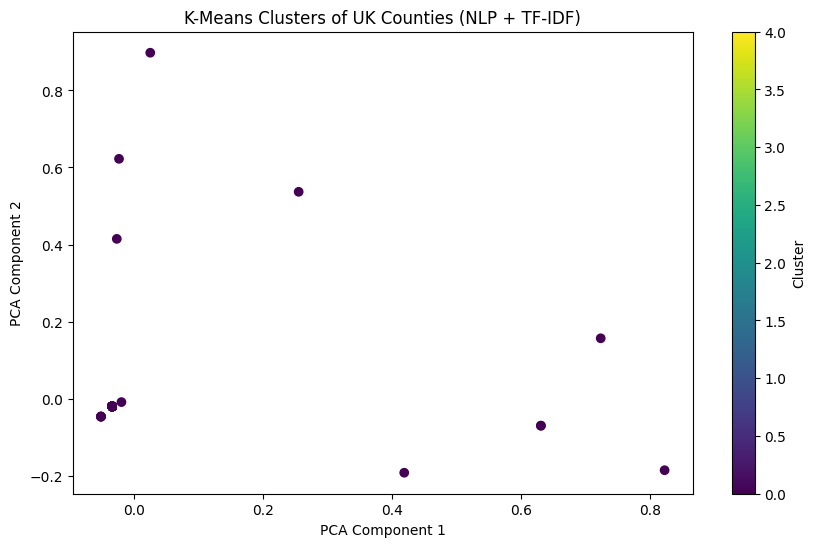

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=df['cluster'], cmap='viridis')

plt.title("K-Means Clusters of UK Counties (NLP + TF-IDF)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(label="Cluster")
plt.show()

In [12]:
for i in range(num_clusters):
    print(f"\nCluster {i}")
    print(df[df['cluster'] == i][text_column].head(10))


Cluster 0
0       bedfordshire
1          berkshire
3     cambridgeshire
4           cheshire
5           cornwall
6            cumbria
7         derbyshire
8              devon
9             dorset
10            durham
Name: county_name, dtype: str

Cluster 1
103    belfast
Name: county_name, dtype: str

Cluster 2
16    herefordshire
Name: county_name, dtype: str

Cluster 3
93    swansea
Name: county_name, dtype: str

Cluster 4
2    buckinghamshire
Name: county_name, dtype: str
